In [3]:
# import Library
from ast import Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
salary_data = pd.read_csv('Salary_Data.csv')
salary_data

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [5]:
X = salary_data.iloc[:, 0].values
y = salary_data.iloc[:, 1].values

In [6]:
y

array([ 39343.,  46205.,  37731.,  43525.,  39891.,  56642.,  60150.,
        54445.,  64445.,  57189.,  63218.,  55794.,  56957.,  57081.,
        61111.,  67938.,  66029.,  83088.,  81363.,  93940.,  91738.,
        98273., 101302., 113812., 109431., 105582., 116969., 112635.,
       122391., 121872.])

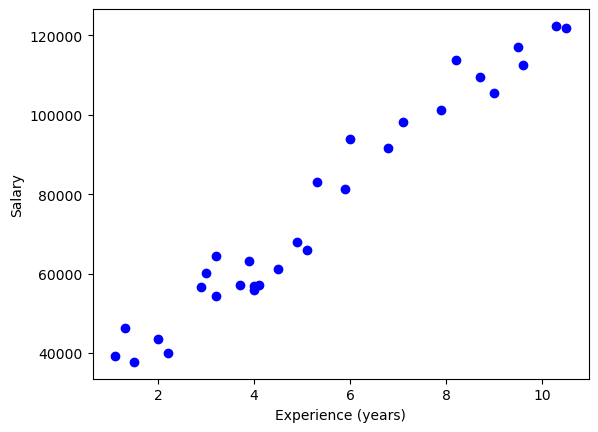

In [7]:
# Visualization

plt.scatter(X, y, c='blue')
plt.xlabel('Experience (years)')
plt.ylabel('Salary')
plt.show()

In [8]:
X = salary_data.iloc[:, 0].values

In [9]:
X = X.reshape(30,1)
X.shape

(30, 1)

In [ ]:
# train_test_split:
# this function splits the dataset into training and testing sets based on the specified test size and random state.
# the method takes in the features (X), target variable (y), test size, and random state as inputs and returns the training and testing sets for both features and target variable.
# example usage:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

def train_test_split(X, y, test_size=0.25, random_state=None):
    X = np.asarray(X)
    y = np.asarray(y)

    if not 0 < test_size < 1:
        raise ValueError("test_size must be between 0 and 1")

    n_total = len(X)
    n_test = int(round(n_total * test_size))

    if random_state is not None:
        rng = np.random.RandomState(random_state)
        indices = rng.permutation(n_total)
    else:
        indices = np.random.permutation(n_total)

    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

In [12]:
print('X_train: ', X_train.shape)
print('y_train: ', y_train.shape)
print('X_test: ', X_test.shape)
print('y_test: ', y_test.shape)

X_train:  (22, 1)
y_train:  (22,)
X_test:  (8, 1)
y_test:  (8,)


In [28]:
# Linear Regression Implementation
# the LinearRegression class implements a simple linear regression model. It has methods for fitting the model to training data and making predictions on new data.
class LinearRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coefficients_ = None

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        X_b = np.c_[np.ones(len(X)), X]
        beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

        self.intercept_ = beta[0]
        self.coefficients_ = beta[1:]
        return self

    def predict(self, X):
        X = np.array(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return self.intercept_ + X @ self.coefficients_

In [29]:
#Fitting Model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

In [30]:
y_test

array([ 37731.,  83088.,  46205.,  57189.,  55794.,  56642.,  81363.,
       109431.])

In [31]:
y_pred = regressor.predict(X_test)
y_pred

array([ 39329.30192021,  75549.80631839,  37422.95958346,  60299.06762442,
        63158.58112954,  52673.69827743,  81268.83332863, 107957.62604308])

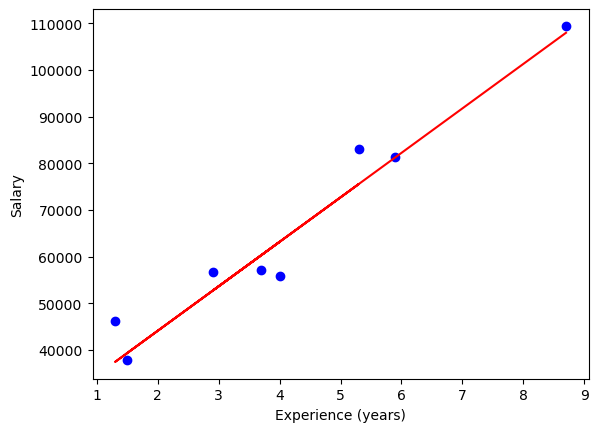

In [32]:
# Visualization

plt.scatter(X_test, y_test, c='blue')
plt.plot(X_test, y_pred, c='r')
plt.xlabel('Experience (years)')
plt.ylabel('Salary')
plt.show()

In [33]:
prediksi = regressor.predict([[4],[8.5]])
prediksi

array([ 63158.58112954, 106051.28370633])

# Algoritma Linear Regression

Linear Regression adalah algoritma yang digunakan untuk mencari hubungan linear antara variabel input $X$ dan target $y$.

Pada kasus sederhana, kita mencoba menggambar garis lurus:

$$
y = b + mX
$$

Keterangan:
- $y$ = nilai target yang diprediksi
- $X$ = fitur/input
- $b$ = intercept
- $m$ = slope atau koefisien

## Tujuan algoritma

Tujuan dari Linear Regression adalah mencari nilai $b$ dan $m$ agar garis yang dibuat sedekat mungkin dengan semua data yang ada.

Artinya, kita ingin meminimalkan selisih antara:
- nilai sebenarnya $y$
- nilai prediksi $\hat{y}$

## Rumus utama

Pada implementasi manual, kita menggunakan metode normal equation:

$$
\beta = (X^T X)^{-1} X^T y
$$

Dimana:
- $X$ = matriks data fitur
- $y$ = vektor target
- $\beta$ = koefisien model
- $X^T$ = transpose matriks $X$
- $(X^T X)^{-1}$ = invers matriks

## Langkah-langkah algoritma

### 1. Ubah data menjadi array
Kode pertama-tama mengubah data menjadi format NumPy:

```python
X = np.array(X, dtype=float)
y = np.array(y, dtype=float)
```

Tujuannya agar operasi matriks bisa dilakukan dengan mudah.

### 2. Jika data 1 dimensi, ubah ke 2 dimensi
Karena model linear biasanya butuh bentuk matriks, maka jika $X$ berbentuk 1D, kita ubah menjadi kolom:

```python
if X.ndim == 1:
    X = X.reshape(-1, 1)
```

Contoh:
- sebelum: `[1, 2, 3, 4]`
- sesudah: `[[1], [2], [3], [4]]`

### 3. Tambahkan kolom bias
Kita menambahkan kolom 1 agar model juga menghitung intercept:

```python
X_b = np.c_[np.ones(len(X)), X]
```

Contoh:

```python
X = [[1], [2], [3]]
```

menjadi:

```python
X_b = [[1, 1],
       [1, 2],
       [1, 3]]
```

Kolom pertama `1` berfungsi untuk intercept.

### 4. Hitung koefisien
Lalu kita menghitung:

```python
beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
```

Rumusnya adalah:

$$
\beta = (X_b^T X_b)^{-1} X_b^T y
$$

Hasilnya adalah:
- intercept
- koefisien slope

### 5. Simpan hasil model
Kode menyimpan parameter tersebut:

```python
self.intercept_ = beta[0]
self.coefficients_ = beta[1:]
```

Artinya:
- `intercept_` = nilai $b$
- `coefficients_` = nilai $m$

### 6. Prediksi
Setelah model sudah belajar, kita bisa memprediksi data baru:

```python
return self.intercept_ + X @ self.coefficients_
```

Ini sama dengan:

$$
\hat{y} = b + mX
$$

## Penjelasan kode lengkap

```python
class LinearRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coefficients_ = None

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        X_b = np.c_[np.ones(len(X)), X]
        beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

        self.intercept_ = beta[0]
        self.coefficients_ = beta[1:]
        return self

    def predict(self, X):
        X = np.array(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return self.intercept_ + X @ self.coefficients_
```

## Intuisi sederhana

Bayangkan Anda punya data pengalaman kerja dan gaji seperti ini:

- 1 tahun → 3.000.000
- 2 tahun → 4.000.000
- 3 tahun → 5.000.000
- 4 tahun → 6.000.000

Maka Linear Regression akan mencari garis lurus terbaik yang paling dekat dengan semua titik tersebut.

Jadi, model belajar:
- berapa kenaikan gaji tiap tahun
- berapa gaji awal saat pengalaman 0

## Kesimpulan

Algoritma Linear Regression bekerja dengan cara:

1. Menyiapkan data input dan target
2. Menambahkan kolom bias
3. Menghitung koefisien menggunakan rumus matriks
4. Menyimpan intercept dan slope
5. Menggunakan nilai tersebut untuk prediksi

Itulah dasar dari model Linear Regression.
